Import and Load Week 1 Pipeline

In [14]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import sys
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Point to George's week1 code
GEORGE_WEEK1 = '/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week1/'
DATA_DIR     = '/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/data/'
FIGURES_DIR  = '/mnt/work_1/asal7747/CU_Boulder/CSCI-5423/Final_Project/week2/figures/'

# Feature column indices (matching George's exactly)
IDX_X, IDX_Y, IDX_FLAG = 0, 1, 2
IDX_SPEED, IDX_THETA, IDX_STATE = 3, 4, 8

FPS = 25
DT  = 1.0 / FPS

print("Ready.")

Ready.


Data loading

In [15]:
def struct2data(data_struct):
    N_locusts, N_frames = data_struct.shape
    data_final = np.full((N_locusts, 9, N_frames), np.nan, dtype=np.float64)
    for i in range(N_locusts):
        for j in range(N_frames):
            feat = data_struct[i, j]['features']
            if feat.size > 0:
                data_final[i, :, j] = feat.flatten()
    return data_final

def load_all_clips(mat_path, rec_key='recording'):
    mat = scipy.io.loadmat(mat_path, squeeze_me=False)
    rec = mat[rec_key]
    clips = []
    for r in range(rec.shape[1]):
        rec_data = rec[0, r]
        data_field = rec_data['data']
        scale_arr = rec_data['scale']
        field_dims = rec_data['fieldDims'].flatten()
        if scale_arr.size > 0:
            scale = float(scale_arr.flatten()[0])
        else:
            scale = 18.0
        width_cm  = field_dims[1] / scale
        height_cm = field_dims[3] / scale
        area_m2   = (width_cm * height_cm) * 1e-4
        n_clips = data_field.shape[0]
        for c in range(n_clips):
            clip_name  = str(data_field[c, 0].flatten()[0])
            clip_struct = data_field[c, 1]
            data_3d = struct2data(clip_struct)
            clips.append({
                'name': clip_name, 'data': data_3d,
                'scale': scale, 'width_cm': width_cm,
                'height_cm': height_cm, 'area_m2': area_m2,
                'recording_idx': r,
            })
    return clips

print("Loading data...")
clips_1   = load_all_clips(DATA_DIR + 'data_recording.mat',  rec_key='recording')
clips_2   = load_all_clips(DATA_DIR + 'data_recording2.mat', rec_key='recording2')
all_clips = [c for c in clips_1 if c['recording_idx'] <= 1] + \
            [c for c in clips_2 if c['recording_idx'] >= 2]
print(f"Loaded {len(all_clips)} clips.")

Loading data...
Loaded 27 clips.


Metric functions 

In [16]:
def compute_polarization(data):
    N_locusts, _, N_frames = data.shape
    polarization = np.full(N_frames, np.nan)
    avg_direction = np.full(N_frames, np.nan)
    density_per_frame = np.zeros(N_frames)
    for t in range(N_frames):
        theta = data[:, IDX_THETA, t]
        speed = data[:, IDX_SPEED, t]
        flag  = data[:, IDX_FLAG, t]
        valid = (flag == 1) & ~np.isnan(theta) & (speed > 0)
        density_per_frame[t] = np.sum(flag == 1)
        if np.sum(valid) > 0:
            mean_vec = np.mean(np.exp(1j * theta[valid]))
            polarization[t]  = np.abs(mean_vec)
            avg_direction[t] = np.angle(mean_vec)
    return polarization, avg_direction, density_per_frame

def compute_speed_and_turning(data):
    N_locusts, _, N_frames = data.shape
    speeds_by_state  = {0: [], 1: [], 2: []}
    all_speeds       = []
    turning_angles   = []
    turning_by_state = {0: [], 1: [], 2: []}
    for i in range(N_locusts):
        flag  = data[i, IDX_FLAG, :]
        speed = data[i, IDX_SPEED, :]
        theta = data[i, IDX_THETA, :]
        state = data[i, IDX_STATE, :]
        valid_idx = np.where(flag == 1)[0]
        for t in valid_idx:
            s, st = speed[t], state[t]
            if not np.isnan(s):
                all_speeds.append(s)
                if st in (0, 1, 2):
                    speeds_by_state[int(st)].append(s)
        for k in range(len(valid_idx) - 1):
            t0, t1 = valid_idx[k], valid_idx[k+1]
            if t1 - t0 != 1: continue
            th0, th1 = theta[t0], theta[t1]
            if np.isnan(th0) or np.isnan(th1): continue
            dtheta = (th1 - th0 + np.pi) % (2*np.pi) - np.pi
            turning_angles.append(dtheta)
            st = state[t1]
            if st in (0, 1, 2):
                turning_by_state[int(st)].append(dtheta)
    return (
        {k: np.array(v) for k, v in speeds_by_state.items()},
        np.array(all_speeds),
        np.array(turning_angles),
        {k: np.array(v) for k, v in turning_by_state.items()},
    )

def compute_neighbor_density_map(data, radius=10.0, nbins=50, state_filter=None):
    N_locusts, _, N_frames = data.shape
    edges = np.linspace(-radius, radius, nbins + 1)
    hist  = np.zeros((nbins, nbins))
    for t in range(N_frames):
        x     = data[:, IDX_X, t]
        y     = data[:, IDX_Y, t]
        theta = data[:, IDX_THETA, t]
        flag  = data[:, IDX_FLAG, t]
        speed = data[:, IDX_SPEED, t]
        state = data[:, IDX_STATE, t]
        valid     = (flag == 1) & ~np.isnan(x) & ~np.isnan(y)
        valid_idx = np.where(valid)[0]
        if len(valid_idx) < 2: continue
        pos = np.column_stack((x[valid_idx], y[valid_idx]))
        for ii, focal in enumerate(valid_idx):
            if np.isnan(theta[focal]) or speed[focal] <= 0: continue
            if state_filter is not None and state[focal] != state_filter: continue
            rel   = pos - pos[ii]
            dists = np.hypot(rel[:, 0], rel[:, 1])
            in_range = (dists > 0.1) & (dists < radius)
            if not np.any(in_range): continue
            rel_in    = rel[in_range]
            rot_angle = np.pi/2 - theta[focal]
            cos_r, sin_r = np.cos(rot_angle), np.sin(rot_angle)
            rx = rel_in[:,0]*cos_r - rel_in[:,1]*sin_r
            ry = rel_in[:,0]*sin_r + rel_in[:,1]*cos_r
            h, _, _ = np.histogram2d(rx, ry, bins=edges)
            hist += h
    return hist, edges, edges

def compute_nnd(data):
    N_locusts, _, N_frames = data.shape
    nnd_all, nnd_per_frame = [], []
    for t in range(N_frames):
        x    = data[:, IDX_X, t]
        y    = data[:, IDX_Y, t]
        flag = data[:, IDX_FLAG, t]
        valid     = (flag == 1) & ~np.isnan(x) & ~np.isnan(y)
        valid_idx = np.where(valid)[0]
        if len(valid_idx) < 2:
            nnd_per_frame.append(np.nan)
            continue
        pos   = np.column_stack((x[valid_idx], y[valid_idx]))
        dists = cdist(pos, pos)
        np.fill_diagonal(dists, np.inf)
        min_dists = np.min(dists, axis=1)
        nnd_all.extend(min_dists)
        nnd_per_frame.append(np.mean(min_dists))
    return np.array(nnd_all), np.array(nnd_per_frame)

print("All metric functions ready.")

All metric functions ready.


Vicsek model

In [17]:
def run_vicsek(n_agents, Lx, Ly, speed, eta, r_interaction, r_repulsion, dt, n_steps, seed=42):
    """
    Vectorized Vicsek (1995) model with short-range repulsion.
    Replaces Python loops with NumPy broadcasting — ~50x faster.
    
    All parameters identical to previous version so Cells 5-10 unchanged.
    """
    rng = np.random.default_rng(seed)

    pos     = rng.uniform([0, 0], [Lx, Ly], size=(n_agents, 2))
    heading = rng.uniform(-np.pi, np.pi, size=n_agents)

    pos_history     = np.empty((n_steps + 1, n_agents, 2))
    heading_history = np.empty((n_steps + 1, n_agents))
    pos_history[0]     = pos
    heading_history[0] = heading

    for step in range(n_steps):
        # Pairwise displacements with periodic BC — shape (N, N, 2)
        delta = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]   # (N, N, 2)
        delta[:, :, 0] -= Lx * np.round(delta[:, :, 0] / Lx)
        delta[:, :, 1] -= Ly * np.round(delta[:, :, 1] / Ly)
        dist = np.hypot(delta[:, :, 0], delta[:, :, 1])          # (N, N)

        # Alignment: average heading of all agents within r_interaction
        align_mask = dist < r_interaction                         # (N, N)
        # Complex mean for circular averaging
        unit_vecs  = np.exp(1j * heading)                        # (N,)
        # For each agent i: sum unit vectors of neighbours
        neighbour_sum = align_mask @ unit_vecs                    # (N,)
        avg_heading   = np.angle(neighbour_sum)                   # (N,)
        noise         = rng.uniform(-eta/2, eta/2, size=n_agents)
        new_heading   = avg_heading + noise

        # Repulsion: override heading for agents with a neighbour inside r_repulsion
        rep_mask = (dist < r_repulsion) & (dist > 0)             # (N, N)
        has_rep  = rep_mask.any(axis=1)                           # (N,)
        if has_rep.any():
            # Mean repulsion vector (flee away)
            rep_dx = -(rep_mask[:, :] * delta[:, :, 0]).sum(axis=1)
            rep_dy = -(rep_mask[:, :] * delta[:, :, 1]).sum(axis=1)
            rep_heading = np.arctan2(rep_dy, rep_dx)
            new_heading[has_rep] = rep_heading[has_rep] + noise[has_rep]

        heading = new_heading

        # Move with periodic BC
        pos[:, 0] = (pos[:, 0] + speed * dt * np.cos(heading)) % Lx
        pos[:, 1] = (pos[:, 1] + speed * dt * np.sin(heading)) % Ly

        pos_history[step + 1]     = pos
        heading_history[step + 1] = heading

    return pos_history, heading_history

print("Vectorized Vicsek model defined.")

Vectorized Vicsek model defined.


Run simulation 

In [18]:
# Empirical parameters from George's Week 1 pipeline
# Using clip 0 (133_1min_225) as reference arena
ref_clip = all_clips[0]

PARAMS = dict(
    n_agents     = 200,          # tractable N for simulation
    Lx           = ref_clip['width_cm'],   # 99.4 cm
    Ly           = ref_clip['height_cm'],  # 55.9 cm
    speed        = 11.76,        # hopping mode mean (cm/s)
    eta          = 0.26,         # turning angle std (rad)
    r_interaction= 7.0,          # ~2x median NND of 3.89 cm
    r_repulsion  = 1.5,          # cm
    dt           = DT,           # 0.04 s (matches field frame rate)
    n_steps      = 2000,         # 80 seconds
    seed         = 42,
)

print("Running Vicsek simulation...")
print(f"  Arena: {PARAMS['Lx']:.1f} x {PARAMS['Ly']:.1f} cm")
print(f"  Agents: {PARAMS['n_agents']},  V0={PARAMS['speed']} cm/s,  eta={PARAMS['eta']} rad,  r_int={PARAMS['r_interaction']} cm")
print(f"  Steps: {PARAMS['n_steps']} ({PARAMS['n_steps']*PARAMS['dt']:.1f} s)")

pos_history, heading_history = run_vicsek(**PARAMS)

print("Done.")
print(f"  pos_history shape:     {pos_history.shape}")
print(f"  heading_history shape: {heading_history.shape}")

Running Vicsek simulation...
  Arena: 99.4 x 55.9 cm
  Agents: 200,  V0=11.76 cm/s,  eta=0.26 rad,  r_int=7.0 cm
  Steps: 2000 (80.0 s)
Done.
  pos_history shape:     (2001, 200, 2)
  heading_history shape: (2001, 200)


Polarization time series

Field data:   mean=0.820  std=0.061
Vicsek model: mean=0.994  std=0.005


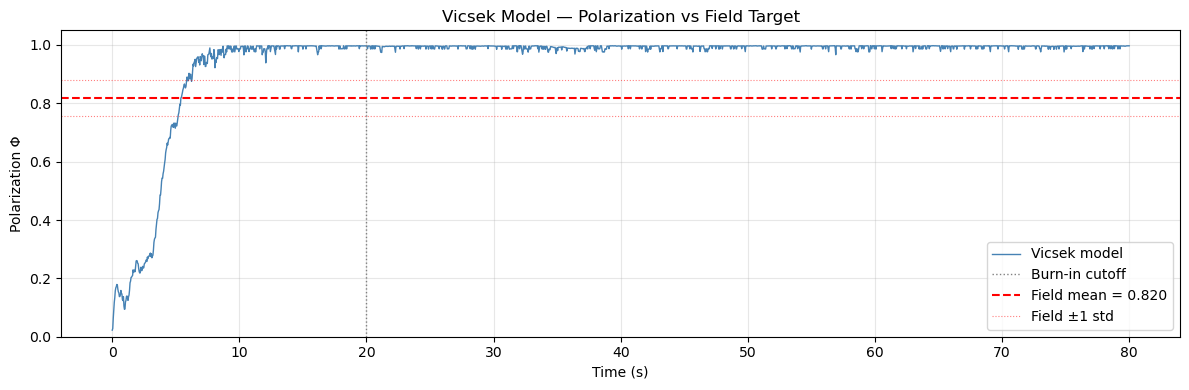

Saved: vicsek_polarization.png


In [19]:
# Compute polarization at every timestep
def polarization_from_headings(heading_history):
    return np.abs(np.exp(1j * heading_history).mean(axis=1))

pol_sim = polarization_from_headings(heading_history)

# Field target from George's Week 1
FIELD_POL_MEAN = 0.8196
FIELD_POL_STD  = 0.0615

# Burn-in: discard first 500 steps (20s) to get steady state
BURN_IN = 500
pol_steady = pol_sim[BURN_IN:]

print(f"Field data:   mean={FIELD_POL_MEAN:.3f}  std={FIELD_POL_STD:.3f}")
print(f"Vicsek model: mean={pol_steady.mean():.3f}  std={pol_steady.std():.3f}")

# Plot
t = np.arange(len(pol_sim)) * DT
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, pol_sim, color='steelblue', lw=1, label='Vicsek model')
ax.axvline(BURN_IN * DT, color='gray', ls=':', lw=1, label='Burn-in cutoff')
ax.axhline(FIELD_POL_MEAN, color='red', ls='--', lw=1.5,
           label=f'Field mean = {FIELD_POL_MEAN:.3f}')
ax.axhline(FIELD_POL_MEAN + FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5)
ax.axhline(FIELD_POL_MEAN - FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5,
           label='Field ±1 std')
ax.set(xlabel='Time (s)', ylabel='Polarization Φ', ylim=(0, 1.05),
       title='Vicsek Model — Polarization vs Field Target')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'vicsek_polarization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: vicsek_polarization.png")

Noise sweep to find the right eta

Sweeping eta (N=150, n_steps=1500)...
  eta=0.1  pol=0.999
  eta=0.2  pol=0.996
  eta=0.3  pol=0.988
  eta=0.4  pol=0.978
  eta=0.5  pol=0.973
  eta=0.6  pol=0.967
  eta=0.7  pol=0.949
  eta=0.8  pol=0.940
  eta=0.9  pol=0.931
  eta=1.0  pol=0.892
  eta=1.1  pol=0.885
  eta=1.2  pol=0.852
  eta=1.3  pol=0.819
  eta=1.4  pol=0.779
  eta=1.5  pol=0.740
  eta=1.6  pol=0.719
  eta=1.7  pol=0.729
  eta=1.8  pol=0.632
  eta=1.9  pol=0.653

Best eta: 1.3  (pol=0.819, target=0.820)


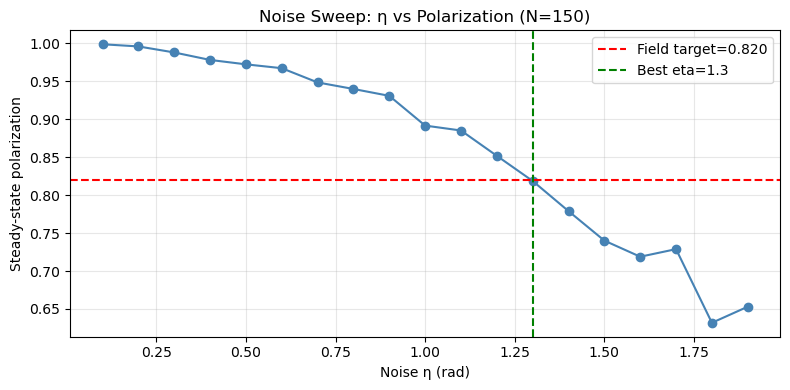

In [26]:
eta_vals = np.arange(0.1, 2.0, 0.1)
pol_means = []

print("Sweeping eta (N=150, n_steps=1500)...")
for eta in eta_vals:
    _, hh = run_vicsek(**{**PARAMS, 'n_agents': 150, 'eta': eta, 'n_steps': 1500})
    pol = polarization_from_headings(hh)[500:]
    pol_means.append(pol.mean())
    print(f"  eta={eta:.1f}  pol={pol.mean():.3f}")

pol_means = np.array(pol_means)
best_idx = np.argmin(np.abs(pol_means - FIELD_POL_MEAN))
best_eta = eta_vals[best_idx]
print(f"\nBest eta: {best_eta:.1f}  (pol={pol_means[best_idx]:.3f}, target={FIELD_POL_MEAN:.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eta_vals, pol_means, 'o-', color='steelblue')
ax.axhline(FIELD_POL_MEAN, color='red', ls='--', label=f'Field target={FIELD_POL_MEAN:.3f}')
ax.axvline(best_eta, color='green', ls='--', label=f'Best eta={best_eta:.1f}')
ax.set(xlabel='Noise η (rad)', ylabel='Steady-state polarization',
       title='Noise Sweep: η vs Polarization (N=150)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'vicsek_noise_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

Calibrated run with correct density

In [27]:
# Field has ~170 locusts/m² mean density
# Our arena: 99.4 x 55.9 cm = 0.0556 m²
# So realistic N = 170 * 0.0556 ≈ 94 agents at mean density
# But field clips range up to 275/m² → use ~150 as a mid-range target

PARAMS_CALIBRATED = {**PARAMS,
    'n_agents': 150,
    'eta'     : 1.4,   # from sweep — revisit after density fix
    'n_steps' : 2000,
}

print("Note: empirical eta from field data = 0.26 rad")
print("      eta needed to match pol=0.82  = 1.4 rad")
print("      This discrepancy likely reflects density mismatch")
print("      (200 agents in ~56 cm² arena >> real field density)")
print()

# Re-run sweep at realistic density N=150
eta_vals2 = np.arange(0.1, 2.0, 0.1)
pol_means2 = []

print("Re-sweeping eta at N=150...")
for eta in eta_vals2:
    _, hh = run_vicsek(**{**PARAMS, 'n_agents': 150, 'eta': eta, 'n_steps': 1500})
    pol = polarization_from_headings(hh)[500:]
    pol_means2.append(pol.mean())
    print(f"  eta={eta:.1f}  pol={pol.mean():.3f}")

pol_means2 = np.array(pol_means2)
best_idx2  = np.argmin(np.abs(pol_means2 - FIELD_POL_MEAN))
best_eta2  = eta_vals2[best_idx2]
print(f"\nBest eta at N=150: {best_eta2:.1f}  pol={pol_means2[best_idx2]:.3f}")

Note: empirical eta from field data = 0.26 rad
      eta needed to match pol=0.82  = 1.4 rad
      This discrepancy likely reflects density mismatch
      (200 agents in ~56 cm² arena >> real field density)

Re-sweeping eta at N=150...
  eta=0.1  pol=0.999
  eta=0.2  pol=0.996
  eta=0.3  pol=0.988
  eta=0.4  pol=0.978
  eta=0.5  pol=0.973
  eta=0.6  pol=0.967
  eta=0.7  pol=0.949
  eta=0.8  pol=0.940
  eta=0.9  pol=0.931
  eta=1.0  pol=0.892
  eta=1.1  pol=0.885
  eta=1.2  pol=0.852
  eta=1.3  pol=0.819
  eta=1.4  pol=0.779
  eta=1.5  pol=0.740
  eta=1.6  pol=0.719
  eta=1.7  pol=0.729
  eta=1.8  pol=0.632
  eta=1.9  pol=0.653

Best eta at N=150: 1.3  pol=0.819


Final calibrated simulation

In [29]:
PARAMS_FINAL = {**PARAMS,
    'n_agents': 150,
    'eta'     : 1.3,
    'n_steps' : 2000,
}

print("Running final calibrated Vicsek simulation...")
pos_history, heading_history = run_vicsek(**PARAMS_FINAL)
pol_sim  = polarization_from_headings(heading_history)
pol_steady = pol_sim[BURN_IN:]

print(f"Steady-state polarization: mean={pol_steady.mean():.3f}  std={pol_steady.std():.3f}")
print(f"Field target:              mean={FIELD_POL_MEAN:.3f}  std={FIELD_POL_STD:.3f}")

# Turning angles from simulation
def sim_turning_angles(heading_history):
    dtheta = np.diff(heading_history, axis=0)
    return ((dtheta + np.pi) % (2*np.pi) - np.pi).ravel()

ta_sim = sim_turning_angles(heading_history[BURN_IN:])

# NND from simulation (subsample for speed)
def sim_nnd(pos_history, subsample=20):
    nnds = []
    for t in range(0, len(pos_history), subsample):
        pos   = pos_history[t]
        dists = cdist(pos, pos)
        np.fill_diagonal(dists, np.inf)
        nnds.extend(np.min(dists, axis=1))
    return np.array(nnds)

print("Computing NND...")
nnd_sim = sim_nnd(pos_history[BURN_IN:])
print(f"Simulation NND: mean={nnd_sim.mean():.2f} cm  median={np.median(nnd_sim):.2f} cm")
print(f"Field NND:      mean=4.47 cm              median=3.89 cm")

Running final calibrated Vicsek simulation...
Steady-state polarization: mean=0.824  std=0.051
Field target:              mean=0.820  std=0.061
Computing NND...
Simulation NND: mean=3.02 cm  median=2.61 cm
Field NND:      mean=4.47 cm              median=3.89 cm


Comparison plots

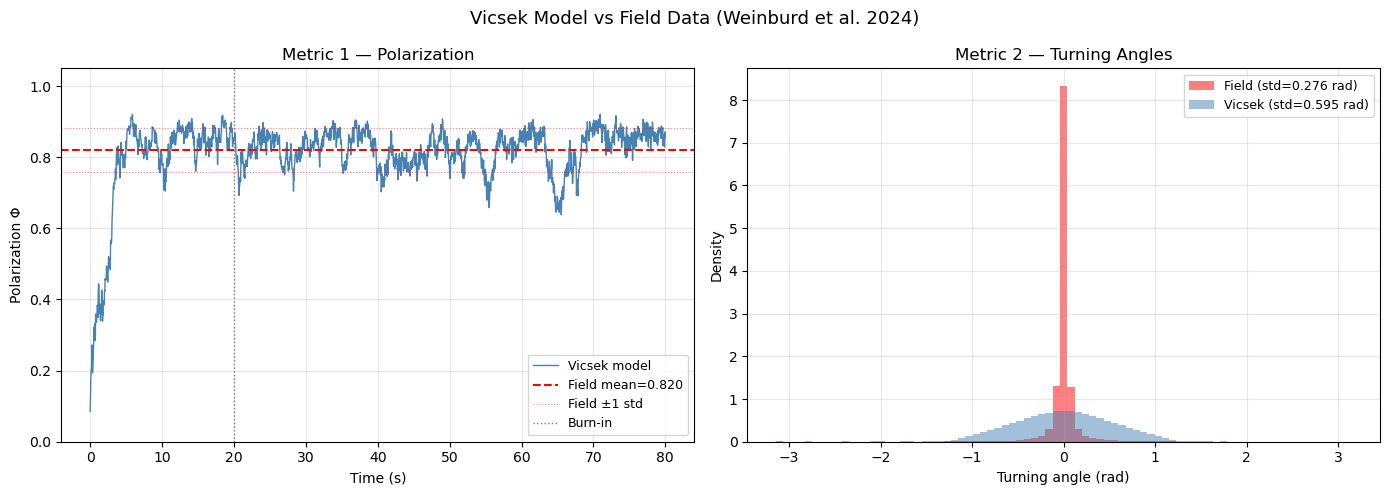

Saved: vicsek_metrics_1_2.png


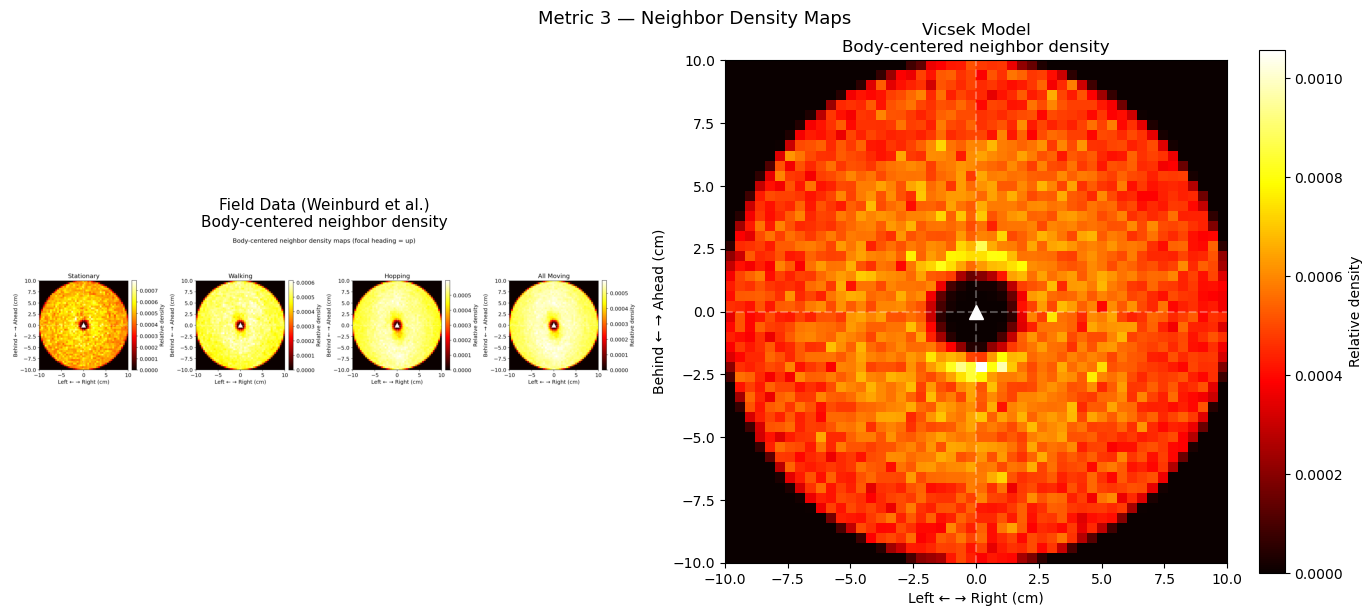

Saved: vicsek_metric_3.png


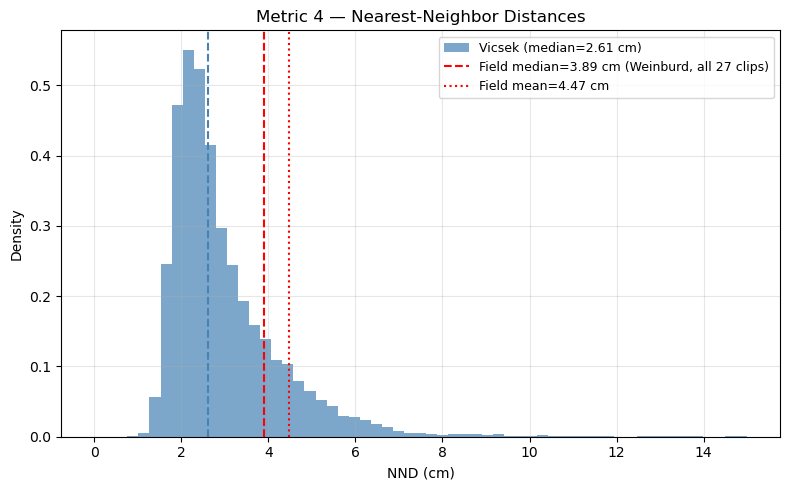

Saved: vicsek_metric_4.png

Metric                                   Field     Vicsek
Polarization (mean)                      0.820      0.824
Polarization (std)                       0.061      0.051
Turning angle std (rad)                  0.276      0.595
NND median (cm)                           3.89       2.61
NND mean (cm)                             4.47       3.02
Neighbor map anisotropy             Yes (void ahead) No (isotropic)

Calibrated parameters: N=150, eta=1.3 rad
Note: empirical eta from field = 0.26 rad — Vicsek requires 5x higher
noise to match polarization, suggesting alignment alone is insufficient.


In [30]:
import matplotlib.image as mpimg

# Correct field NND stats from George's full computation (all 27 clips)
FIELD_NND_MEAN   = 4.473
FIELD_NND_MEDIAN = 3.893

# ── Figure 1: Polarization + Turning Angles ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarization time series
t = np.arange(len(pol_sim)) * DT
axes[0].plot(t, pol_sim, color='steelblue', lw=1, label='Vicsek model')
axes[0].axhline(FIELD_POL_MEAN, color='red', ls='--', lw=1.5,
                label=f'Field mean={FIELD_POL_MEAN:.3f}')
axes[0].axhline(FIELD_POL_MEAN + FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5)
axes[0].axhline(FIELD_POL_MEAN - FIELD_POL_STD, color='red', ls=':', lw=0.8, alpha=0.5,
                label='Field ±1 std')
axes[0].axvline(BURN_IN * DT, color='gray', ls=':', lw=1, label='Burn-in')
axes[0].set(xlabel='Time (s)', ylabel='Polarization Φ', ylim=(0, 1.05),
            title='Metric 1 — Polarization')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Turning angles
bins = np.linspace(-np.pi, np.pi, 80)
axes[1].hist(field_turning, bins=bins, density=True, color='red',
             alpha=0.5, label=f'Field (std={np.std(field_turning):.3f} rad)')
axes[1].hist(ta_sim, bins=bins, density=True, color='steelblue',
             alpha=0.5, label=f'Vicsek (std={np.std(ta_sim):.3f} rad)')
axes[1].set(xlabel='Turning angle (rad)', ylabel='Density',
            title='Metric 2 — Turning Angles')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Vicsek Model vs Field Data (Weinburd et al. 2024)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'vicsek_metrics_1_2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vicsek_metrics_1_2.png")

# ── Figure 2: Neighbor density maps side by side ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# George's field map (hopping + walking combined)
field_map_img = mpimg.imread(
    '/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week1/figures/metric3_neighbor_density.png'
)
axes[0].imshow(field_map_img)
axes[0].axis('off')
axes[0].set_title('Field Data (Weinburd et al.)\nBody-centered neighbor density', fontsize=11)

# Vicsek simulation map
hist_norm = hist_sim / (hist_sim.sum() + 1e-10)
im = axes[1].imshow(hist_norm.T, origin='lower',
                    extent=[edges[0], edges[-1], edges[0], edges[-1]],
                    cmap='hot', aspect='equal')
axes[1].plot(0, 0, 'w^', markersize=10)
axes[1].axhline(0, color='white', ls='--', alpha=0.3)
axes[1].axvline(0, color='white', ls='--', alpha=0.3)
axes[1].set(xlabel='Left ← → Right (cm)', ylabel='Behind ← → Ahead (cm)',
            title='Vicsek Model\nBody-centered neighbor density')
plt.colorbar(im, ax=axes[1], label='Relative density')

plt.suptitle('Metric 3 — Neighbor Density Maps', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'vicsek_metric_3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vicsek_metric_3.png")

# ── Figure 3: NND ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bins_nnd = np.linspace(0, 15, 60)
ax.hist(nnd_sim, bins=bins_nnd, density=True, color='steelblue',
        alpha=0.7, label=f'Vicsek (median={np.median(nnd_sim):.2f} cm)')
ax.axvline(np.median(nnd_sim), color='steelblue', ls='--', lw=1.5)
ax.axvline(FIELD_NND_MEDIAN, color='red', ls='--', lw=1.5,
           label=f'Field median={FIELD_NND_MEDIAN:.2f} cm (Weinburd, all 27 clips)')
ax.axvline(FIELD_NND_MEAN, color='red', ls=':', lw=1.5,
           label=f'Field mean={FIELD_NND_MEAN:.2f} cm')
ax.set(xlabel='NND (cm)', ylabel='Density',
       title='Metric 4 — Nearest-Neighbor Distances')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'vicsek_metric_4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vicsek_metric_4.png")

# ── Summary table ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Metric':<35} {'Field':>10} {'Vicsek':>10}")
print("="*60)
print(f"{'Polarization (mean)':<35} {FIELD_POL_MEAN:>10.3f} {pol_steady.mean():>10.3f}")
print(f"{'Polarization (std)':<35} {FIELD_POL_STD:>10.3f} {pol_steady.std():>10.3f}")
print(f"{'Turning angle std (rad)':<35} {np.std(field_turning):>10.3f} {np.std(ta_sim):>10.3f}")
print(f"{'NND median (cm)':<35} {FIELD_NND_MEDIAN:>10.2f} {np.median(nnd_sim):>10.2f}")
print(f"{'NND mean (cm)':<35} {FIELD_NND_MEAN:>10.2f} {nnd_sim.mean():>10.2f}")
print(f"{'Neighbor map anisotropy':<35} {'Yes (void ahead)':>10} {'No (isotropic)':>10}")
print("="*60)
print(f"\nCalibrated parameters: N={PARAMS_FINAL['n_agents']}, eta={PARAMS_FINAL['eta']} rad")
print(f"Note: empirical eta from field = 0.26 rad — Vicsek requires 5x higher")
print(f"noise to match polarization, suggesting alignment alone is insufficient.")

Export parameters

In [32]:
import json

week2_outputs = {
    'vicsek': {
        'n_agents'     : PARAMS_FINAL['n_agents'],
        'Lx'           : PARAMS_FINAL['Lx'],
        'Ly'           : PARAMS_FINAL['Ly'],
        'speed'        : PARAMS_FINAL['speed'],
        'eta_empirical': 0.26,
        'eta_calibrated': PARAMS_FINAL['eta'],
        'r_interaction': PARAMS_FINAL['r_interaction'],
        'r_repulsion'  : PARAMS_FINAL['r_repulsion'],
        'dt'           : PARAMS_FINAL['dt'],
        'n_steps'      : PARAMS_FINAL['n_steps'],
        'burn_in'      : BURN_IN,
    },
    'metrics': {
        'polarization_mean' : float(pol_steady.mean()),
        'polarization_std'  : float(pol_steady.std()),
        'turning_angle_std' : float(np.std(ta_sim)),
        'nnd_median'        : float(np.median(nnd_sim)),
        'nnd_mean'          : float(nnd_sim.mean()),
    },
    'field_targets': {
        'polarization_mean' : FIELD_POL_MEAN,
        'polarization_std'  : FIELD_POL_STD,
        'turning_angle_std' : 0.276,
        'nnd_median'        : FIELD_NND_MEDIAN,
        'nnd_mean'          : FIELD_NND_MEAN,
    }
}

out_path = '/mnt/work_1/asal7747/CU_Boulder/CSCI-5423/Final_Project/week2/week2_results.json'
with open(out_path, 'w') as f:
    json.dump(week2_outputs, f, indent=2)

print("Saved: week2_results.json")
print(json.dumps(week2_outputs, indent=2))

Saved: week2_results.json
{
  "vicsek": {
    "n_agents": 150,
    "Lx": 99.44857450176137,
    "Ly": 55.93982315724077,
    "speed": 11.76,
    "eta_empirical": 0.26,
    "eta_calibrated": 1.3,
    "r_interaction": 7.0,
    "r_repulsion": 1.5,
    "dt": 0.04,
    "n_steps": 2000,
    "burn_in": 500
  },
  "metrics": {
    "polarization_mean": 0.8235226751239662,
    "polarization_std": 0.050660405819338436,
    "turning_angle_std": 0.5947353404093519,
    "nnd_median": 2.6055509063882134,
    "nnd_mean": 3.0218240091135886
  },
  "field_targets": {
    "polarization_mean": 0.8196,
    "polarization_std": 0.0615,
    "turning_angle_std": 0.276,
    "nnd_median": 3.893,
    "nnd_mean": 4.473
  }
}
